<a href="https://colab.research.google.com/github/ruhaan-reza/Machine-Learning/blob/Main/Insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [160]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [161]:
url = "https://raw.githubusercontent.com/ruhaan-reza/Machine-Learning/Part-1/insurance.csv"

df = pd.read_csv(url)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# **EDA**

In [162]:
df.shape

(1338, 7)

In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [164]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [165]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [166]:
numeric_columns = ['age', 'bmi', 'children', 'charges']

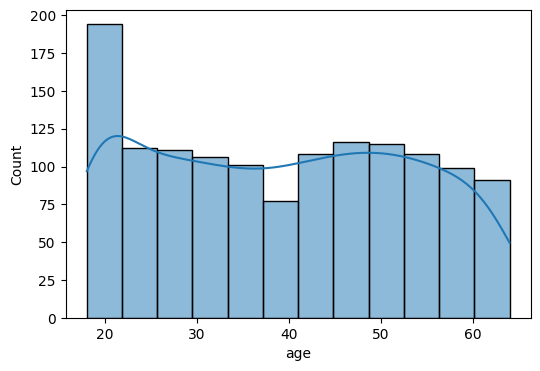

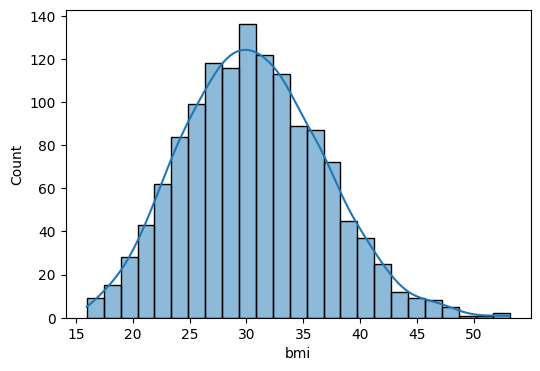

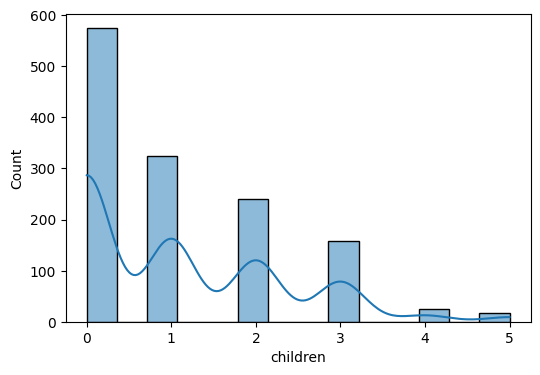

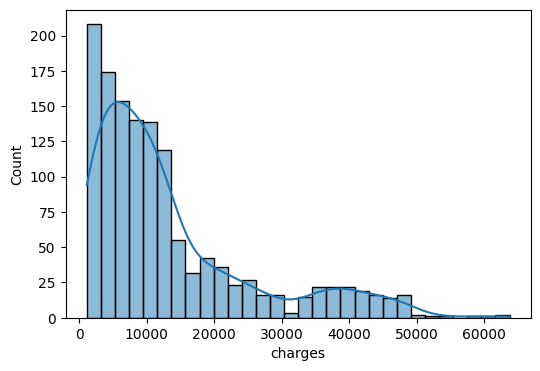

In [167]:
for column in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=column, kde=True)

<Axes: xlabel='children', ylabel='count'>

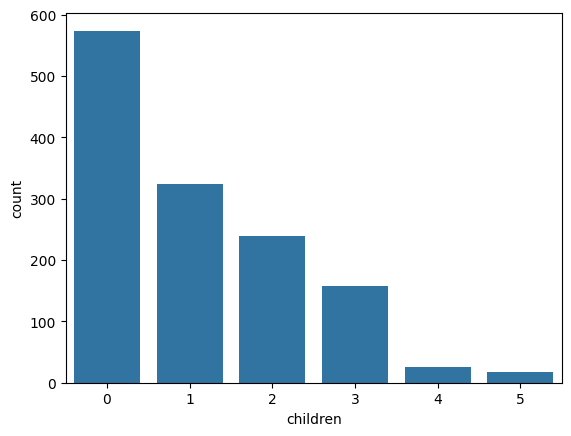

In [168]:
sns.countplot(x= df['children'])

<Axes: xlabel='sex', ylabel='count'>

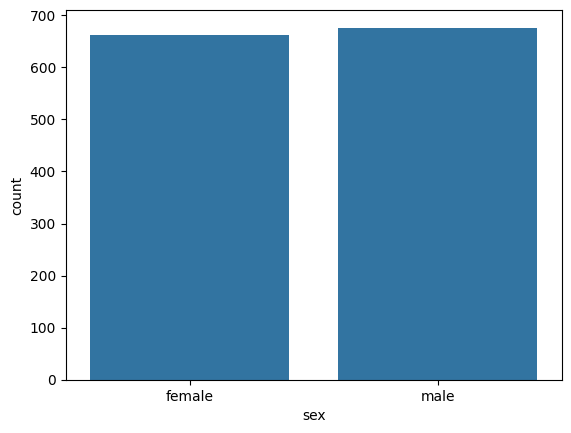

In [169]:
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

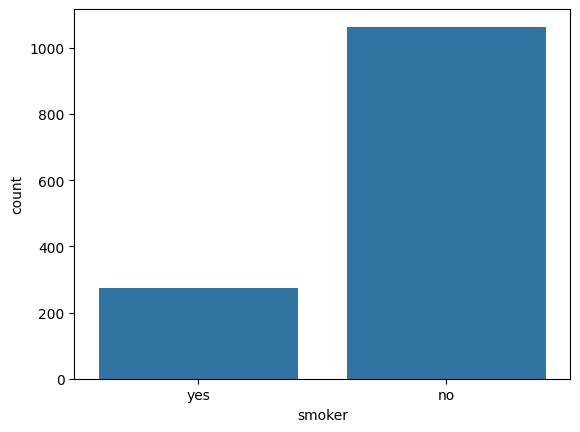

In [170]:
sns.countplot(x=df['smoker'])

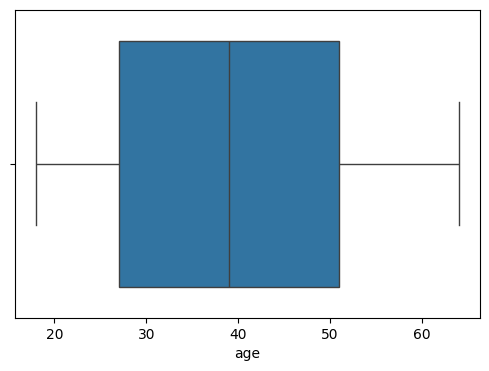

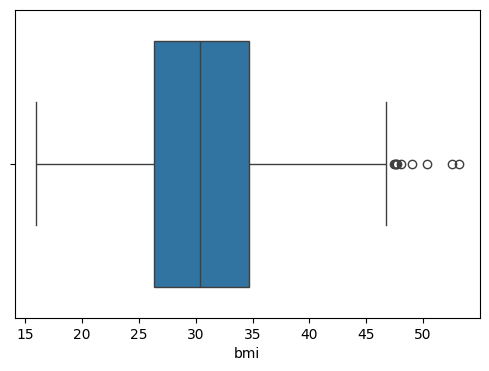

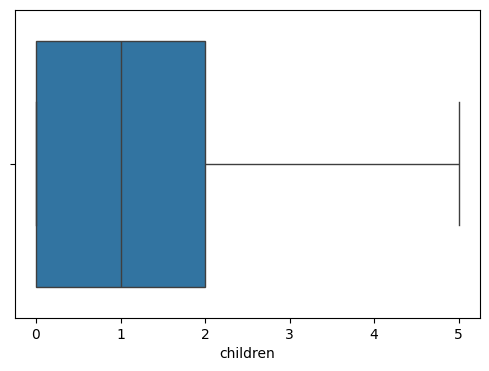

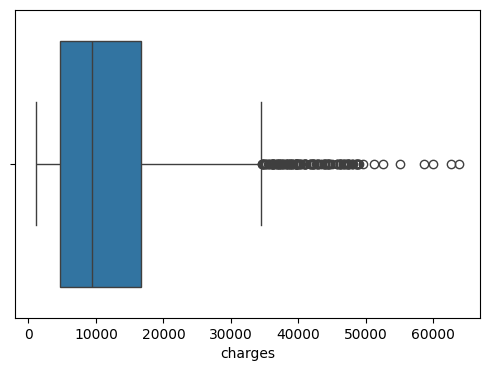

In [171]:
for column in numeric_columns:
  plt.figure(figsize=(6, 4))
  sns.boxplot(data=df, x=column)

<Axes: >

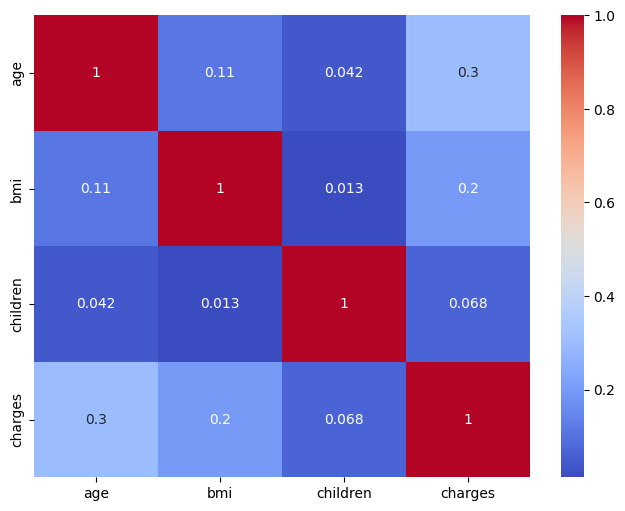

In [172]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

# Data Preprocessing

In [173]:
df_cleaned = df.copy()

In [174]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [175]:
df_cleaned.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [176]:
df_cleaned['sex'].value_counts()

,count
sex,
male,676
female,662


In [177]:
df_cleaned['sex'] = df_cleaned['sex'].map({'male': 0, 'female': 1})

In [178]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [179]:
df_cleaned['smoker'].value_counts()

,count
smoker,
no,1064
yes,274


In [180]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'yes': 1, 'no': 0})

In [181]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [182]:
df_cleaned.rename(columns={'sex': 'is_female','smoker': 'is_smoker'}, inplace=True)

In [183]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [184]:
df_cleaned['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


In [185]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['region'], prefix=['region'])

In [186]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False


In [187]:
df_cleaned = df_cleaned.astype(int)

In [188]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0


# Feature Engineering and Extraction

<Axes: xlabel='bmi', ylabel='Count'>

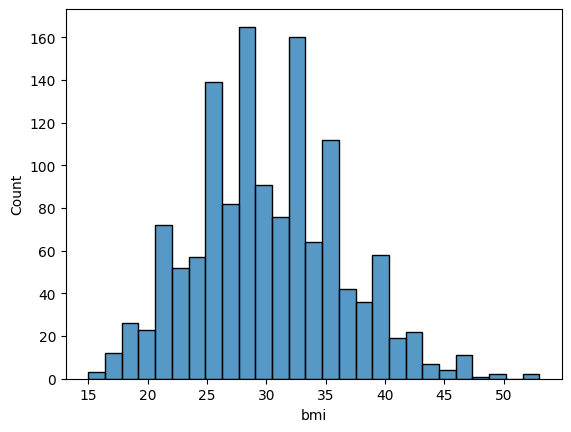

In [189]:
sns.histplot(df_cleaned['bmi'])

In [190]:
df_cleaned['bmi_category'] = pd.cut(df_cleaned['bmi'],
              bins=[0, 18.5, 24.9, 29.9, float('inf')],
              labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

In [191]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,0,1,Overweight
1,18,0,33,1,0,1725,0,0,1,0,Obese
2,28,0,33,3,0,4449,0,0,1,0,Obese
3,33,0,22,0,0,21984,0,1,0,0,Normal
4,32,0,28,0,0,3866,0,1,0,0,Overweight


In [192]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['bmi_category'], drop_first=True)

In [193]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,0,1,False,True,False
1,18,0,33,1,0,1725,0,0,1,0,False,False,True
2,28,0,33,3,0,4449,0,0,1,0,False,False,True
3,33,0,22,0,0,21984,0,1,0,0,True,False,False
4,32,0,28,0,0,3866,0,1,0,0,False,True,False


In [194]:
df_cleaned = df_cleaned.astype(int)

In [195]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,1,0


In [196]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_Normal', 'bmi_category_Overweight',
       'bmi_category_Obese'],
      dtype='object')

In [197]:
from sklearn.preprocessing import StandardScaler
cols = ['age','bmi','children']
scaler = StandardScaler()
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [198]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.438764,1,-0.518122,-0.908614,1,16884,0,0,0,1,0,1,0
1,-1.509965,0,0.462657,-0.078767,0,1725,0,0,1,0,0,0,1
2,-0.797954,0,0.462657,1.580926,0,4449,0,0,1,0,0,0,1
3,-0.441948,0,-1.335438,-0.908614,0,21984,0,1,0,0,1,0,0
4,-0.513149,0,-0.354659,-0.908614,0,3866,0,1,0,0,0,1,0


In [199]:
from scipy.stats import pearsonr

selected_features = [
    'age', 'bmi', 'children', 'is_female', 'is_smoker',
    'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest','bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

correlations = {
    feature :
    pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}
correlaion_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlaion_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
4,is_smoker,0.787251
0,age,0.299009
11,bmi_category_Obese,0.199533
1,bmi,0.196188
7,region_southeast,0.073981
2,children,0.067999
5,region_northeast,0.006350
6,region_northwest,-0.039905
8,region_southwest,-0.043210
3,is_female,-0.057293


In [200]:
cat_features = [
    'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

In [201]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
is_smoker,854.020268,0.0,Reject Null (Keep Feature)
region_southeast,15.208814,0.001647,Reject Null (Keep Feature)
is_female,9.532132,0.022992,Reject Null (Keep Feature)
bmi_category_Obese,8.510101,0.036566,Reject Null (Keep Feature)
region_southwest,5.530825,0.136807,Accept Null (Drop Feature)
bmi_category_Overweight,4.620089,0.201826,Accept Null (Drop Feature)
bmi_category_Normal,3.578987,0.310661,Accept Null (Drop Feature)
region_northwest,1.226112,0.746749,Accept Null (Drop Feature)


In [202]:
final_df = df_cleaned[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges','region_southeast','bmi_category_Obese']]

In [203]:
final_df

,age,is_female,bmi,children,is_smoker,charges,region_southeast,bmi_category_Obese
0,-1.438764,1,-0.518122,-0.908614,1,16884,0,0
1,-1.509965,0,0.462657,-0.078767,0,1725,1,1
2,-0.797954,0,0.462657,1.580926,0,4449,1,1
3,-0.441948,0,-1.335438,-0.908614,0,21984,0,0
4,-0.513149,0,-0.354659,-0.908614,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.768473,0,-0.027733,1.580926,0,10600,0,1
1334,-1.509965,1,0.135731,-0.908614,0,2205,0,1
1335,-1.509965,1,0.953046,-0.908614,0,1629,1,1
1336,-1.296362,1,-0.845048,-0.908614,0,2007,0,0


# Model Creation

In [204]:
from sklearn.model_selection import train_test_split

X = final_df.drop('charges', axis=1)
y = final_df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [205]:
from sklearn.linear_model import LinearRegression

In [206]:
model = LinearRegression()

In [207]:
model.fit(X_train, y_train)

LinearRegression()

In [208]:
y_pred = model.predict(X_test)

In [209]:
from sklearn.metrics import  r2_score

r2 = r2_score(y_test, y_pred)
r2
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
adjusted_r2

0.775385049051806